# Morocco Structural Transformation Lab

This notebook investigates how employment has shifted across Agriculture, Industry, and Services in Morocco between 2015 and 2025.

The objective is to identify which sectors are gaining or losing labor share and evaluate the structural transformation of the Moroccan economy.

## 1. Loading Libraries and Processed Dataset

We begin by importing the required Python libraries and loading the processed econometric dataset generated during the data engineering pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/processed/morocco_master_econometrics.csv")

df = df.sort_values("Year").reset_index(drop=True)

print(df.shape)

df.head()

(11, 23)


,Year,Y_Total,Y_Primary,Y_Secondary,Y_Tertiary,L_Total,L_Primary,L_Secondary,L_Tertiary,Prod_Total_Scaled,...,Prod_Total_Index,Prod_Primary_Index,Prod_Secondary_Index,Prod_Tertiary_Index,Rel_Prod_Primary,Rel_Prod_Secondary,Rel_Prod_Tertiary,Share_L_Primary,Share_L_Secondary,Share_L_Tertiary
0,2015.0,104.300000,114.000000,101.800000,102.100000,10651654.0,4162470.0,2187965.0,4301219.0,9.791906,...,77.621286,68.089856,96.645574,90.589244,2.796961,4.751603,2.424192,0.390782,0.205411,0.403808
1,2016.0,104.821500,92.796000,103.734200,105.469300,10662327.0,4055740.0,2252003.0,4354584.0,9.831015,...,77.931305,56.883700,95.681409,92.431891,2.327345,4.685486,2.463661,0.380380,0.211211,0.408408
2,2017.0,110.167396,110.891220,107.261163,108.949787,10651654.0,3746223.0,2401425.0,4504006.0,10.342750,...,81.987872,73.592273,92.778648,92.314489,2.861986,4.318545,2.338791,0.351703,0.225451,0.422846
3,2018.0,113.582586,115.881325,110.586259,112.109331,10662327.0,3671512.0,2390752.0,4600063.0,10.652701,...,84.444881,78.468831,96.081816,93.008026,2.962844,4.342171,2.287801,0.344344,0.224224,0.431431
4,2019.0,116.876481,111.361953,115.120295,116.481595,10662327.0,3468725.0,2401425.0,4792177.0,10.961630,...,86.893783,79.817046,99.576632,92.761316,2.928814,4.373285,2.217427,0.325325,0.225225,0.449449


## 2. Building the Sectoral Dataset

This section extracts the core sectoral variables required for the shift-share analysis:
- Sectoral output
- Sectoral employment

The economy is decomposed into:
- Agriculture
- Industry
- Services

In [2]:
sector_data = pd.DataFrame({
    "Year": df["Year"],
    "Agriculture_Output": df["Y_Primary"],
    "Industry_Output": df["Y_Secondary"],
    "Services_Output": df["Y_Tertiary"],
    "Agriculture_Employment": df["L_Primary"],
    "Industry_Employment": df["L_Secondary"],
    "Services_Employment": df["L_Tertiary"]
})

sector_data.head()

,Year,Agriculture_Output,Industry_Output,Services_Output,Agriculture_Employment,Industry_Employment,Services_Employment
0,2015.0,114.000000,101.800000,102.100000,4162470.0,2187965.0,4301219.0
1,2016.0,92.796000,103.734200,105.469300,4055740.0,2252003.0,4354584.0
2,2017.0,110.891220,107.261163,108.949787,3746223.0,2401425.0,4504006.0
3,2018.0,115.881325,110.586259,112.109331,3671512.0,2390752.0,4600063.0
4,2019.0,111.361953,115.120295,116.481595,3468725.0,2401425.0,4792177.0


## 3. Computing Sectoral Growth Rates

We calculate annual percentage growth rates for:
- Employment
- Output

This allows us to compare labor dynamics with sectoral production dynamics.

In [3]:
growth_df = pd.DataFrame()

growth_df["Year"] = sector_data["Year"]

growth_df["Agri_Emp_Growth"] = sector_data["Agriculture_Employment"].pct_change() * 100
growth_df["Ind_Emp_Growth"] = sector_data["Industry_Employment"].pct_change() * 100
growth_df["Serv_Emp_Growth"] = sector_data["Services_Employment"].pct_change() * 100

growth_df["Agri_Output_Growth"] = sector_data["Agriculture_Output"].pct_change() * 100
growth_df["Ind_Output_Growth"] = sector_data["Industry_Output"].pct_change() * 100
growth_df["Serv_Output_Growth"] = sector_data["Services_Output"].pct_change() * 100

growth_df.head()

,Year,Agri_Emp_Growth,Ind_Emp_Growth,Serv_Emp_Growth,Agri_Output_Growth,Ind_Output_Growth,Serv_Output_Growth
0,2015.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2016.0,-2.564103,2.926829,1.240695,-18.6,1.9,3.3
2,2017.0,-7.631579,6.635071,3.431373,19.5,3.4,3.3
3,2018.0,-1.994302,-0.444444,2.132701,4.5,3.1,2.9
4,2019.0,-5.523256,0.446429,4.176334,-3.9,4.1,3.9


## 4. Estimating National Employment Growth

This section computes the average national employment growth rate over the study period.

This value serves as the benchmark for the shift-share decomposition.

In [4]:
national_emp_growth = (
    df["L_Total"].pct_change().mean()
)

print("Average national employment growth:")
print(round(national_emp_growth * 100, 3), "%")

Average national employment growth:
0.02 %


## 5. Constructing the Shift-Share Decomposition

The shift-share framework compares sectoral employment growth to national employment growth.

The objective is to identify:
- sectors outperforming the national trend,
- sectors lagging behind the aggregate economy.

In [5]:
shift_share = pd.DataFrame()

shift_share["Sector"] = [
    "Agriculture",
    "Industry",
    "Services"
]

employment_cols = [
    "L_Primary",
    "L_Secondary",
    "L_Tertiary"
]

sector_growth_rates = []

for col in employment_cols:
    growth = df[col].pct_change().mean()
    sector_growth_rates.append(growth)

shift_share["Sector_Growth"] = sector_growth_rates

shift_share["National_Growth"] = national_emp_growth

shift_share["Industry_Mix"] = (
    shift_share["Sector_Growth"]
    - shift_share["National_Growth"]
)

shift_share

,Sector,Sector_Growth,National_Growth,Industry_Mix
0,Agriculture,-0.041372,0.0002,-0.041572
1,Industry,0.019398,0.0002,0.019198
2,Services,0.021259,0.0002,0.021058


## 6. Estimating Competitive Effects

The competitive effect measures whether a sector creates employment faster or slower than the national average.

Positive values indicate relative sectoral dynamism.
Negative values indicate structural decline or weak labor absorption.

In [6]:
shift_share["Competitive_Effect"] = (
    shift_share["Sector_Growth"]
    - shift_share["National_Growth"]
)

shift_share

,Sector,Sector_Growth,National_Growth,Industry_Mix,Competitive_Effect
0,Agriculture,-0.041372,0.0002,-0.041572,-0.041572
1,Industry,0.019398,0.0002,0.019198,0.019198
2,Services,0.021259,0.0002,0.021058,0.021058


## 7. Visualizing Sector Competitive Effects

The following visualization highlights which sectors contribute positively or negatively to employment dynamics in Morocco.

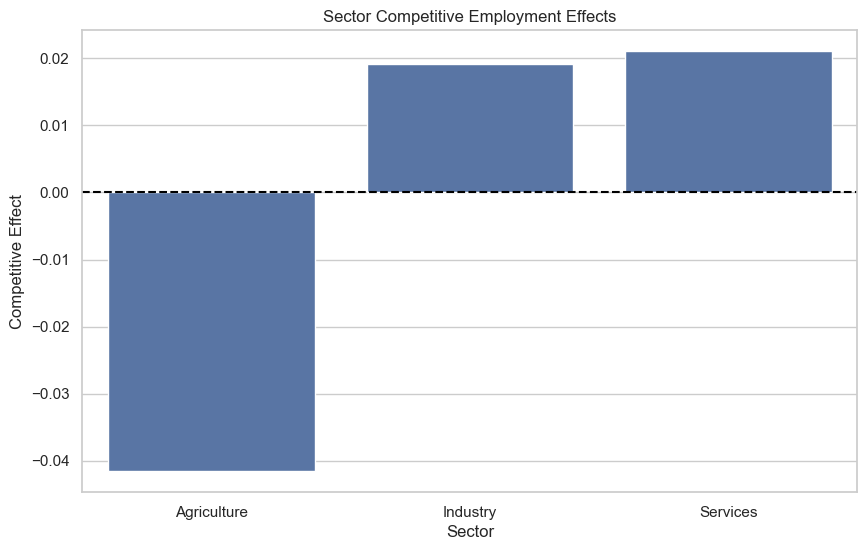

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=shift_share,
    x="Sector",
    y="Competitive_Effect"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Sector Competitive Employment Effects")

plt.ylabel("Competitive Effect")

plt.xlabel("Sector")

plt.show()

## 8. Visualizing Industry Mix Effects

This chart illustrates how sector-specific growth patterns differ from the national employment trend.

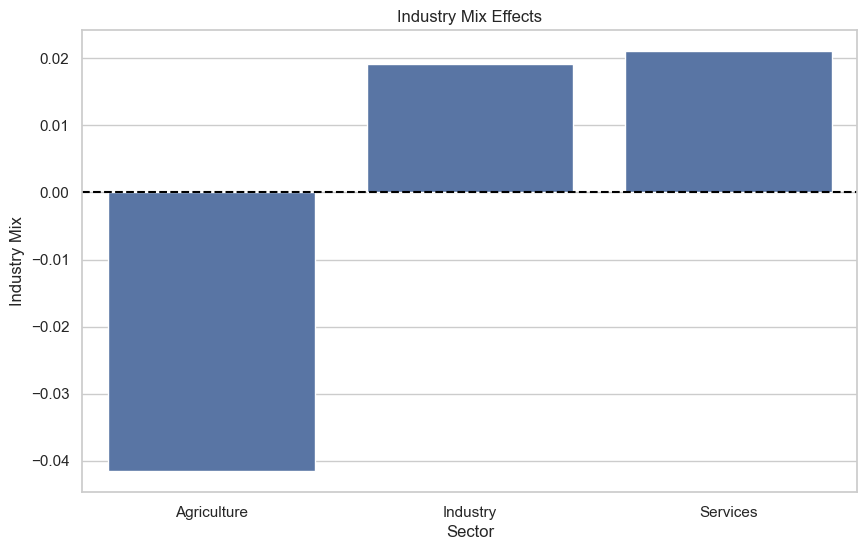

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=shift_share,
    x="Sector",
    y="Industry_Mix"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Industry Mix Effects")

plt.ylabel("Industry Mix")

plt.xlabel("Sector")

plt.show()

## 9. Building the Final Summary Table

The results are converted into percentage terms for easier interpretation and reporting.

In [9]:
summary_table = shift_share.copy()

summary_table["Sector_Growth"] = (
    summary_table["Sector_Growth"] * 100
)

summary_table["National_Growth"] = (
    summary_table["National_Growth"] * 100
)

summary_table["Industry_Mix"] = (
    summary_table["Industry_Mix"] * 100
)

summary_table["Competitive_Effect"] = (
    summary_table["Competitive_Effect"] * 100
)

summary_table = summary_table.round(3)

summary_table

,Sector,Sector_Growth,National_Growth,Industry_Mix,Competitive_Effect
0,Agriculture,-4.137,0.02,-4.157,-4.157
1,Industry,1.940,0.02,1.920,1.920
2,Services,2.126,0.02,2.106,2.106


## 10. Creating Export Directories

This step ensures that the output folders exist before exporting tables and figures.

In [11]:
import os

os.makedirs("../outputs/tables", exist_ok=True)

## 11. Exporting Results

The final shift-share decomposition table is exported as a CSV file for reproducibility and future analysis.

In [12]:
summary_table.to_csv(
    "../outputs/tables/shift_share_results.csv",
    index=False
)

## 12. Structural Transformation Analysis

This section evaluates how labor allocation changed between 2015 and 2025.

The analysis measures whether employment shares shifted:
- away from agriculture,
- toward industry,
- or toward services.

In [13]:
structural_change = pd.DataFrame()

structural_change["Sector"] = [
    "Agriculture",
    "Industry",
    "Services"
]

structural_change["Employment_Share_2015"] = [
    df.loc[0, "Share_L_Primary"],
    df.loc[0, "Share_L_Secondary"],
    df.loc[0, "Share_L_Tertiary"]
]

structural_change["Employment_Share_2025"] = [
    df.loc[df.index[-1], "Share_L_Primary"],
    df.loc[df.index[-1], "Share_L_Secondary"],
    df.loc[df.index[-1], "Share_L_Tertiary"]
]

structural_change["Change"] = (
    structural_change["Employment_Share_2025"]
    - structural_change["Employment_Share_2015"]
)

structural_change = structural_change.round(3)

structural_change

,Sector,Employment_Share_2015,Employment_Share_2025,Change
0,Agriculture,0.391,0.255,-0.136
1,Industry,0.205,0.248,0.043
2,Services,0.404,0.497,0.093


## 13. Visualizing Structural Change

The chart below illustrates the direction and magnitude of employment share reallocation across sectors over the study period.

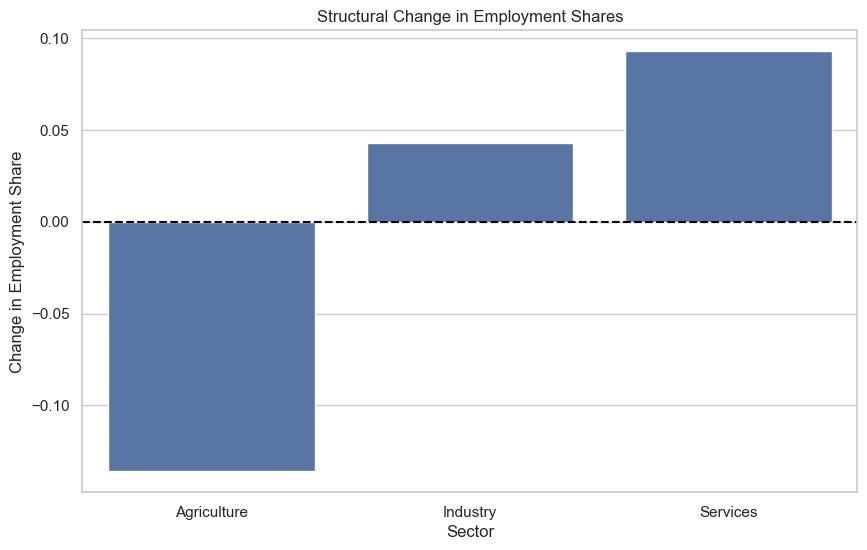

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=structural_change,
    x="Sector",
    y="Change"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Structural Change in Employment Shares")

plt.ylabel("Change in Employment Share")

plt.xlabel("Sector")

plt.show()